In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.extmath import randomized_svd

from src.utils.grid import build_xyz
from src.decomposition.tucker import perform_tucker, reconstruct, perform_tucker_rpca
from src.decomposition.rpca import randomized_rpca
from src.potential.poisson_solver import poisson_solve
from src.potential.charge_potential import v_analytic_gaussian

In [21]:
N = 51
L = 6.0
alpha = 1.0

dx = L / N
eps = dx / 2
xyz = build_xyz(N, L)
R = np.sqrt(xyz[0]**2 + xyz[1]**2 + xyz[2]**2)

rho_grid = np.exp(-alpha * R**2)

print(f"rho max/min = {rho_grid.max():.4f} / {rho_grid.min():.4f}")

rho max/min = 1.0000 / 0.0000


## 指数関数による展開近似

In [22]:
from src.approximation.exp_sum import (
    ExponentialSum,
    LogUniformGrid,
    VarproOptimizer,
    BenchmarkRunner,
)

fit_grid = LogUniformGrid(r_min=1e-2, r_max=2*np.sqrt(3)*L, n_points=2000)
eval_grid = LogUniformGrid(r_min=1e-2, r_max=2*np.sqrt(3)*L, n_points=2000)

optimizer = VarproOptimizer(
    fit_grid=fit_grid,
    eval_grid=eval_grid,
    nonneg=True,
    max_iter=2000,
)

runner = BenchmarkRunner(
    optimizer=optimizer,
    ranks=[2, 4, 6, 8, 10, 15, 20, 30],
)
fits = runner.run()

   R      L2 rel err      L∞ rel err
------------------------------------
   2       7.898e-01       1.000e+00
   4       6.292e-01       1.000e+00
   6       4.656e-01       1.000e+00
   8       2.540e-01       9.938e-01
  10       7.044e-02       4.944e-01
  15       3.630e-03       3.654e-02
  20       2.552e-04       1.227e-03
  30       9.884e-06       1.154e-04


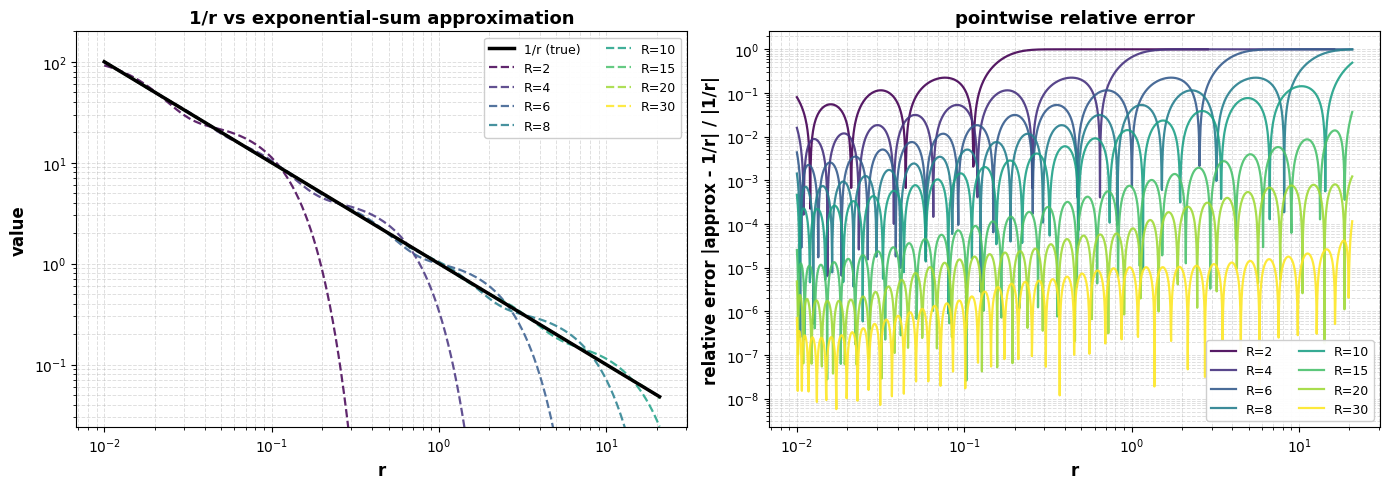

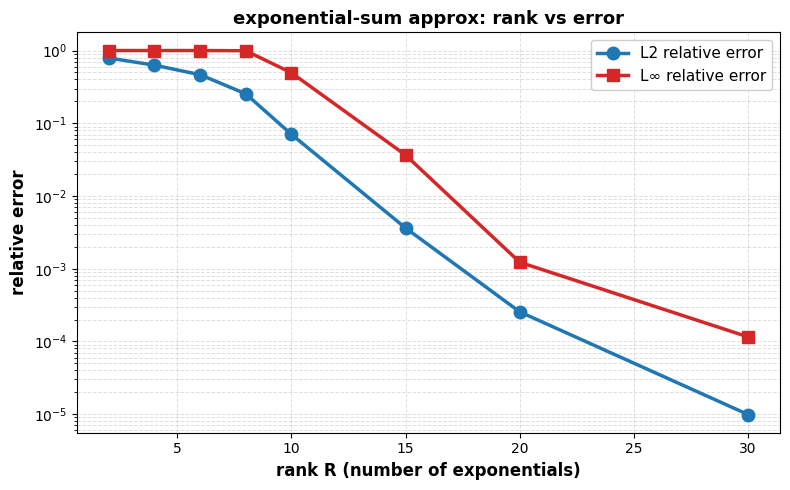

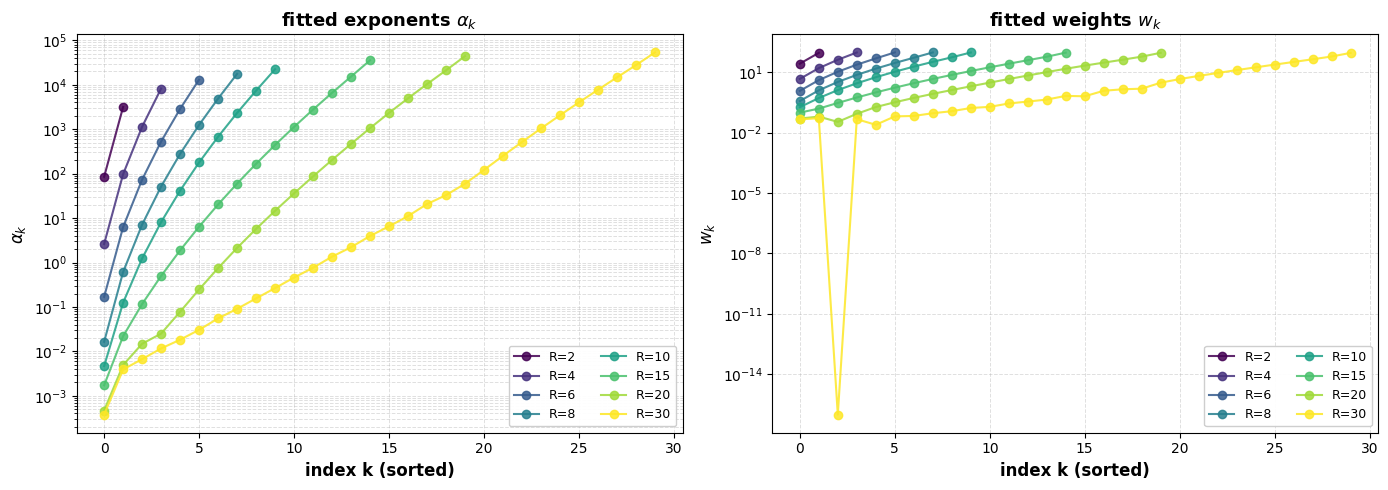

In [23]:
_UNDERFLOW_THRESHOLD = 1e-300


def _masked_loglog(ax, x, y, **kwargs):
    """y > threshold の点のみ loglog プロット（アンダーフロー除外）。"""
    valid = y > _UNDERFLOW_THRESHOLD
    if valid.any():
        ax.loglog(x[valid], y[valid], **kwargs)


def _make_colormap(n: int):
    cmap = plt.get_cmap("viridis")
    return [cmap(i / max(n - 1, 1)) for i in range(n)]


# ---------------------------------------------------------------------------
# 図1 + 図2: 近似カーブ と 点ごとの相対誤差
# ---------------------------------------------------------------------------

def plot_approximation(fits: dict, eval_grid: LogUniformGrid) -> None:
    r_eval = eval_grid.points
    f_true = 1.0 / r_eval
    ranks = sorted(fits.keys())
    colors = _make_colormap(len(ranks))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.loglog(r_eval, f_true, "k-", lw=2.5, label="1/r (true)", zorder=10)

    for color, r in zip(colors, ranks):
        approx = fits[r].evaluate(r_eval)
        _masked_loglog(ax, r_eval, approx, lw=1.6, ls="--",
                       color=color, alpha=0.85, label=f"R={r}")

    ax.set_ylim(f_true.min() * 0.5, f_true.max() * 2.0)
    ax.set_xlabel("r", fontsize=12, fontweight="bold")
    ax.set_ylabel("value", fontsize=12, fontweight="bold")
    ax.set_title("1/r vs exponential-sum approximation", fontsize=13, fontweight="bold")
    ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    ax2 = axes[1]
    for color, r in zip(colors, ranks):
        approx = fits[r].evaluate(r_eval)
        valid = approx > _UNDERFLOW_THRESHOLD
        if valid.any():
            rel_err = np.abs((approx[valid] - f_true[valid]) / f_true[valid])
            ax2.loglog(r_eval[valid], rel_err, "-", lw=1.6,
                       color=color, alpha=0.9, label=f"R={r}")

    ax2.set_xlabel("r", fontsize=12, fontweight="bold")
    ax2.set_ylabel("relative error |approx - 1/r| / |1/r|",
                   fontsize=12, fontweight="bold")
    ax2.set_title("pointwise relative error", fontsize=13, fontweight="bold")
    ax2.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax2.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 図3: ランク vs L2 / L∞ 誤差
# ---------------------------------------------------------------------------

def plot_rank_vs_error(fits: dict) -> None:
    ranks = sorted(fits.keys())
    l2_errs = [fits[r].l2_error for r in ranks]
    linf_errs = [fits[r].linf_error for r in ranks]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogy(ranks, l2_errs, "o-", markersize=9, lw=2.5,
                label="L2 relative error", color="C0")
    ax.semilogy(ranks, linf_errs, "s-", markersize=9, lw=2.5,
                label="L∞ relative error", color="C3")
    ax.set_xlabel("rank R (number of exponentials)", fontsize=12, fontweight="bold")
    ax.set_ylabel("relative error", fontsize=12, fontweight="bold")
    ax.set_title("exponential-sum approx: rank vs error",
                 fontsize=13, fontweight="bold")
    ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax.legend(fontsize=11, loc="best", framealpha=0.95)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 図4: α_k と w_k の分布
# ---------------------------------------------------------------------------

def plot_param_distribution(fits: dict) -> None:
    ranks = sorted(fits.keys())
    colors = _make_colormap(len(ranks))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for color, r in zip(colors, ranks):
        idx = np.arange(r)
        axes[0].semilogy(idx, fits[r].alphas, "o-", color=color,
                         alpha=0.85, label=f"R={r}", markersize=6)
        axes[1].semilogy(idx, np.maximum(fits[r].weights, 1e-16), "o-",
                         color=color, alpha=0.85, label=f"R={r}", markersize=6)

    for ax, ylabel, title in zip(
        axes,
        [r"$\alpha_k$", r"$w_k$"],
        [r"fitted exponents $\alpha_k$", r"fitted weights $w_k$"],
    ):
        ax.set_xlabel("index k (sorted)", fontsize=12, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
        ax.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    plt.tight_layout()
    plt.show()


plot_approximation(fits, eval_grid)
plot_rank_vs_error(fits)
plot_param_distribution(fits)

In [24]:
V_analytic = v_analytic_gaussian(R, alpha)

In [25]:
"""
coulomb_kernel.py
=================
指数和近似 1/r ≈ Σ_k w_k exp(-α_k r²) を用いた
Hartree ポテンシャルの計算。

    V_H(r1) = ∫ ρ(r2) / |r1-r2| dr2
            ≈ Σ_k w_k ∫ ρ(r2) exp(-α_k|r1-r2|²) dr2

x,y,z の分離性を利用して各方向に 1D カーネルを順次作用させる
（mode-n product）。計算量: O(R · N³) vs 直接法 O(N⁶)。
"""

from __future__ import annotations


# ---------------------------------------------------------------------------
# 1D カーネル行列
# ---------------------------------------------------------------------------

def build_gaussian_kernel_1d(alpha: float, x: np.ndarray) -> np.ndarray:
    """K[i,j] = exp(-alpha * (x_i - x_j)²)  shape: (N, N)"""
    diff = x[:, None] - x[None, :]   # (N, N)
    return np.exp(-alpha * diff ** 2)


# ---------------------------------------------------------------------------
# 3D への作用（mode-n product）
# ---------------------------------------------------------------------------

def apply_1d_kernel_along_axis(K: np.ndarray, rho: np.ndarray, axis: int) -> np.ndarray:
    """
    3D 配列 rho の指定軸に沿って行列 K を作用させる。

    axis=0: V[i,j,k] = Σ_i' K[i,i'] ρ[i',j,k]
    axis=1: V[i,j,k] = Σ_j' K[j,j'] ρ[i,j',k]
    axis=2: V[i,j,k] = Σ_k' K[k,k'] ρ[i,j,k']
    """
    return np.moveaxis(np.tensordot(K, rho, axes=([1], [axis])), 0, axis)


def apply_separable_kernel_3d(alpha: float, x: np.ndarray, rho: np.ndarray) -> np.ndarray:
    """
    exp(-α|r1-r2|²) = exp(-α(x1-x2)²) · exp(-α(y1-y2)²) · exp(-α(z1-z2)²)
    の分離性を利用して各軸に K を順次適用する。
    """
    K = build_gaussian_kernel_1d(alpha, x)
    result = apply_1d_kernel_along_axis(K, rho, axis=0)
    result = apply_1d_kernel_along_axis(K, result, axis=1)
    result = apply_1d_kernel_along_axis(K, result, axis=2)
    return result

対角成分の補正 ($1/r$ に対する近傍積分)

クーロンカーネル $1/r$ を離散化する際、同一セル内（$r=0$）の寄与を正しく評価する必要があります。指数和近似では中心での値が有限値 $\sum w_k$ となり、厳密な特異性を表現できません。
そこで、一辺 $dx$ の立方体領域の内部で $1/r$ を積分した解析値を用いて誤差を補正します。

単位立方体 $[-0.5, 0.5]^3$ における $1/r$ の体積積分は約 `2.38` となることが知られています。
これを用いて、対角成分の真の寄与は変数のスケール変換から以下のように求まります。

$$
K_{\text{diag}} = \frac{1}{dx^3} \iiint_{[-dx/2, dx/2]^3} \frac{1}{r} d^3r \approx \frac{2.38}{dx}
$$

実際の計算では、指数和近似がもつ対角成分 $\sum w_k$ と真の寄与 $2.38/dx$ の差分を加えることで近傍の誤差を補正します。

E_analytic = 1.236941e+01
   R |     1/r L2 | V err (no) | V err (corr) | E err (no) | E err (corr) |     Σw_k
------------------------------------------------------------------------------------------
   2 |  7.898e-01 |  9.927e-01 |    9.961e-01 |  9.735e-01 |    9.860e-01 |  116.810
   4 |  6.292e-01 |  8.859e-01 |    8.893e-01 |  6.029e-01 |    6.205e-01 |  155.893
   6 |  4.656e-01 |  2.368e-01 |    2.351e-01 |  7.990e-02 |    5.893e-02 |  182.025
   8 |  2.540e-01 |  4.382e-02 |    4.374e-02 |  1.228e-02 |    1.129e-02 |  202.158
  10 |  7.044e-02 |  1.783e-02 |    1.194e-02 |  2.513e-02 |    8.649e-04 |  220.802
  15 |  3.630e-03 |  1.635e-02 |    3.846e-04 |  3.098e-02 |    5.324e-04 |  263.408
  20 |  2.552e-04 |  1.792e-02 |    2.826e-04 |  3.397e-02 |    5.260e-04 |  286.419
  30 |  9.884e-06 |  1.951e-02 |    2.811e-04 |  3.699e-02 |    5.263e-04 |  309.717


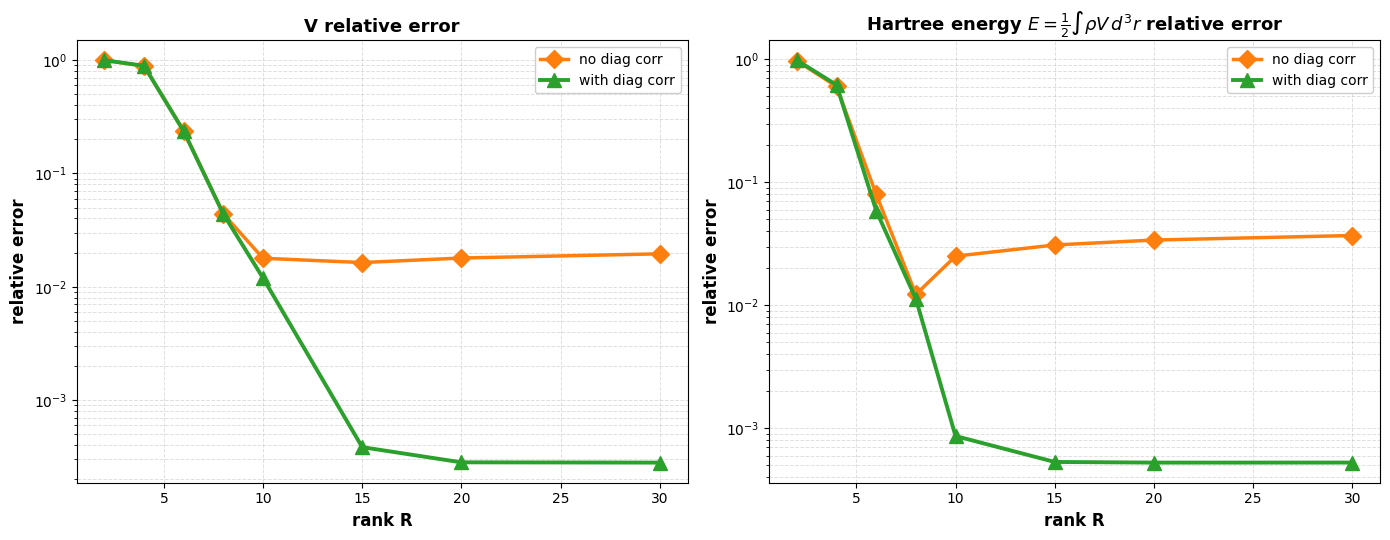

In [26]:
# ===== 各 R に対する V / E 相対誤差 (対角補正あり / なし) =====
x_axis = xyz[0, :, 0, 0]
cell_int_const = 2.38                    # 立方体セル ∫ 1/r d³r / dx²
K_diag_true = cell_int_const / dx

# 解析エネルギー: E = (1/2) ∫ ρ V d³r
E_analytic = 0.5 * np.sum(rho_grid * V_analytic) * dx**3

err_v_no_corr   = {}
err_v_with_corr = {}
err_e_no_corr   = {}
err_e_with_corr = {}

for r, fit in fits.items():
    V_exp = np.zeros_like(rho_grid)
    for w_k, alpha_k in zip(fit.weights, fit.alphas):
        V_exp += w_k * apply_separable_kernel_3d(alpha_k, x_axis, rho_grid)

    V_no   = V_exp * dx**3
    V_corr = (V_exp + (K_diag_true - fit.weights.sum()) * rho_grid) * dx**3

    err_v_no_corr[r]   = np.linalg.norm(V_no   - V_analytic) / np.linalg.norm(V_analytic)
    err_v_with_corr[r] = np.linalg.norm(V_corr - V_analytic) / np.linalg.norm(V_analytic)

    E_no   = 0.5 * np.sum(rho_grid * V_no)   * dx**3
    E_corr = 0.5 * np.sum(rho_grid * V_corr) * dx**3
    err_e_no_corr[r]   = abs(E_no   - E_analytic) / abs(E_analytic)
    err_e_with_corr[r] = abs(E_corr - E_analytic) / abs(E_analytic)

# ----- 表 -----
print(f"E_analytic = {E_analytic:.6e}")
print(f"{'R':>4s} | {'1/r L2':>10s} | "
      f"{'V err (no)':>10s} | {'V err (corr)':>12s} | "
      f"{'E err (no)':>10s} | {'E err (corr)':>12s} | {'Σw_k':>8s}")
print("-" * 90)
for r in sorted(fits):
    print(
        f"{r:>4d} | {fits[r].l2_error:>10.3e} | "
        f"{err_v_no_corr[r]:>10.3e} | {err_v_with_corr[r]:>12.3e} | "
        f"{err_e_no_corr[r]:>10.3e} | {err_e_with_corr[r]:>12.3e} | "
        f"{fits[r].weights.sum():>8.3f}"
    )

# ----- 図 -----
ranks_sorted = sorted(fits.keys())
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.semilogy(ranks_sorted, [err_v_no_corr[r]   for r in ranks_sorted],
            'D-',  markersize=9, lw=2.5, label='no diag corr',   color='C1')
ax.semilogy(ranks_sorted, [err_v_with_corr[r] for r in ranks_sorted],
            '^-',  markersize=10, lw=2.8, label='with diag corr', color='C2')
ax.set_xlabel('rank R', fontsize=12, fontweight='bold')
ax.set_ylabel('relative error', fontsize=12, fontweight='bold')
ax.set_title('V relative error', fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=10, loc='best', framealpha=0.95)

ax = axes[1]
ax.semilogy(ranks_sorted, [err_e_no_corr[r]   for r in ranks_sorted],
            'D-',  markersize=9, lw=2.5, label='no diag corr',   color='C1')
ax.semilogy(ranks_sorted, [err_e_with_corr[r] for r in ranks_sorted],
            '^-',  markersize=10, lw=2.8, label='with diag corr', color='C2')
ax.set_xlabel('rank R', fontsize=12, fontweight='bold')
ax.set_ylabel('relative error', fontsize=12, fontweight='bold')
ax.set_title(r'Hartree energy $E=\frac{1}{2}\int\rho V\,d^3r$ relative error',
             fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=10, loc='best', framealpha=0.95)

plt.tight_layout()
plt.show()


1D kernels factored. Calculating 3D potentials...


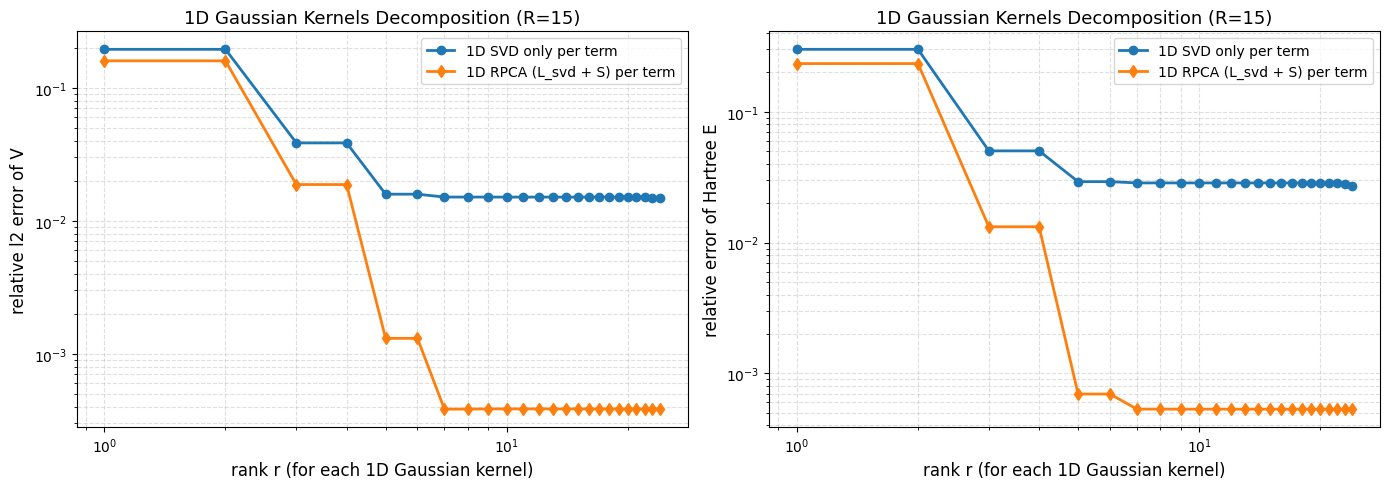

In [ ]:
from src.decomposition.rpca import randomized_rpca
from src.utils.metrics import v_e_errors

exp_sum_R = 15
fit = fits[exp_sum_R]
x_axis = xyz[0, :, 0, 0]

svd_ranks = [i for i in range(1, 26)]  # 各1DガウシアンのSVDランクを1から25まで試す
errors_v_svd_only = []
errors_e_svd_only = []
errors_v_rpca = []
errors_e_rpca = []

# αごとに1Dガウシアンを出してRPCAとSVDを事前計算しておく
K_1d_list = []
RPCA_1d_list = []
for alpha_k in fit.alphas:
    K_1D = build_gaussian_kernel_1d(alpha_k, x_axis)
    K_1d_list.append(K_1D)
    
    # 各1Dガウシアンに対してL+S分解
    L_1d, S_1d = randomized_rpca(K_1D, rank=min(N-1, 20), max_iter=2000, tol=1e-6)
    U_L, S_L, Vt_L = np.linalg.svd(L_1d)
    
    # SVD for comparison
    U_s, S_s, Vt_s = np.linalg.svd(K_1D)
    
    RPCA_1d_list.append({
        'S_1d': S_1d, 'U_L': U_L, 'S_L': S_L, 'Vt_L': Vt_L,
        'U_s': U_s, 'S_s': S_s, 'Vt_s': Vt_s
    })

print("1D kernels factored. Calculating 3D potentials...")

for r in svd_ranks:
    V_svd = np.zeros_like(rho_grid)
    V_rpca = np.zeros_like(rho_grid)
    
    for w_k, k_data in zip(fit.weights, RPCA_1d_list):
        # --- 1) SVD Only (1D) ---
        K_svd_1d = (k_data['U_s'][:, :r] * k_data['S_s'][:r]) @ k_data['Vt_s'][:r, :]
        
        # 3D畳み込み
        V_s_tmp = apply_1d_kernel_along_axis(K_svd_1d, rho_grid, axis=0)
        V_s_tmp = apply_1d_kernel_along_axis(K_svd_1d, V_s_tmp, axis=1)
        V_s_tmp = apply_1d_kernel_along_axis(K_svd_1d, V_s_tmp, axis=2)
        V_svd += w_k * V_s_tmp
        
        # --- 2) RPCA (1D L + S) ---
        L_r_1d = (k_data['U_L'][:, :r] * k_data['S_L'][:r]) @ k_data['Vt_L'][:r, :]
        K_rpca_1d = L_r_1d + k_data['S_1d']
        
        V_r_tmp = apply_1d_kernel_along_axis(K_rpca_1d, rho_grid, axis=0)
        V_r_tmp = apply_1d_kernel_along_axis(K_rpca_1d, V_r_tmp, axis=1)
        V_r_tmp = apply_1d_kernel_along_axis(K_rpca_1d, V_r_tmp, axis=2)
        V_rpca += w_k * V_r_tmp

    # dx**3 & 対角補正
    V_svd_corr = (V_svd + (K_diag_true - fit.weights.sum()) * rho_grid) * dx**3
    V_rpca_corr = (V_rpca + (K_diag_true - fit.weights.sum()) * rho_grid) * dx**3
    
    # 誤差の記録
    err_v_s, err_e_s = v_e_errors(V_svd_corr, V_analytic, rho_grid, dx)
    errors_v_svd_only.append(err_v_s)
    errors_e_svd_only.append(err_e_s)
    
    err_v_rpca, err_e_rpca = v_e_errors(V_rpca_corr, V_analytic, rho_grid, dx)
    errors_v_rpca.append(err_v_rpca)
    errors_e_rpca.append(err_e_rpca)

# プロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].loglog(svd_ranks, errors_v_svd_only, 'o-', lw=2, label='1D SVD only per term')
axes[0].loglog(svd_ranks, errors_v_rpca, 'd-', lw=2, label='1D RPCA (L_svd + S) per term')
axes[0].set_xlabel('rank r (for each 1D Gaussian kernel)', fontsize=12)
axes[0].set_ylabel('relative l2 error of V', fontsize=12)
axes[0].set_title('1D Gaussian Kernels Decomposition (R=15)', fontsize=13)
axes[0].grid(True, which='both', alpha=0.4, ls='--')
axes[0].legend()

axes[1].loglog(svd_ranks, errors_e_svd_only, 'o-', lw=2, label='1D SVD only per term')
axes[1].loglog(svd_ranks, errors_e_rpca, 'd-', lw=2, label='1D RPCA (L_svd + S) per term')
axes[1].set_xlabel('rank r (for each 1D Gaussian kernel)', fontsize=12)
axes[1].set_ylabel('relative error of Hartree E', fontsize=12)
axes[1].set_title('1D Gaussian Kernels Decomposition (R=15)', fontsize=13)
axes[1].grid(True, which='both', alpha=0.4, ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()